<a href="https://colab.research.google.com/github/Sid3839/Invoice-Recognition-System-Using-Deep-Learning/blob/main/siddhant_shendge__invoice_data_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Downloading Dependencies

In [ ]:
!pip install -q -U git+https://github.com/huggingface/transformers.git
!pip install -q -U safetensors
!pip install -q -U torch
!pip install -q -U xformers
!pip install -q -U langchain
!pip install -q -U ctransformers[cuda]
!pip install sentence-transformers
!pip -qqq install bitsandbytes accelerate

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.2.1+cu121 requires torch==2.2.1, but you have torch 2.2.2 which is incompatible.
torchtext 0.17.1 requires torch==2.2.1, but you have torch 2.2.2 which is incompatible.
torchvision 0.17.1+cu121 requires torch==2.2.1, but you have torch 2.2.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.5/222.5 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.7/817.7 kB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.5/287.5 kB 33.0 MB/s eta 0:00:00
   

In [ ]:
import os
os.kill(os.getpid(), 9)

# FIRST WAIT TILL THESE TWO CELLS ARE EXECUTED AND THEN RUN ALL THE NEXY CELLS

In [ ]:
!git clone https://github.com/IDEA-Research/GroundingDINO.git
%cd GroundingDINO
!pip install -e .

Cloning into 'GroundingDINO'...
remote: Enumerating objects: 430, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 430 (delta 148), reused 131 (delta 127), pack-reused 233
Receiving objects: 100% (430/430), 12.86 MiB | 26.98 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/GroundingDINO
Obtaining file:///content/GroundingDINO
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.7/254.7 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 kB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.2.2
    Uninstalling torch-2.2.2:
      Successfully uninstalled torch-2.2.2
  Running setup.py develop for groundingdino
ERROR: pip's dependency resolver 

In [ ]:
%mkdir weights
%cd weights
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
%cd ..

/content/GroundingDINO/weights
/content/GroundingDINO


In [ ]:
import subprocess

# Set locale to UTF-8
subprocess.run('export LC_ALL=C.UTF-8', shell=True)
subprocess.run('export LANG=C.UTF-8', shell=True)

# Install the package
subprocess.run('pip install git+https://github.com/facebookresearch/segment-anything.git', shell=True)


CompletedProcess(args='pip install git+https://github.com/facebookresearch/segment-anything.git', returncode=0)

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
!git clone https://huggingface.co/spaces/abhishek/StableSAM/
!mkdir -p /content/GroundingDINO/checkpoints/
%mv /content/GroundingDINO/StableSAM/sam_vit_h_4b8939.pth /content/GroundingDINO/checkpoints/sam_vit_h_4b8939.pth

Cloning into 'StableSAM'...
remote: Enumerating objects: 73, done.
remote: Total 73 (delta 0), reused 0 (delta 0), pack-reused 73
Unpacking objects: 100% (73/73), 32.07 KiB | 995.00 KiB/s, done.


In [ ]:
!pip install pytesseract
!sudo apt-get install tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 45 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (5,840 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debc

In [ ]:
!pip install gradio
!pip install PyMuPDF


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 47.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 35.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 9.5 MB/s eta 0:00:00
  Created wheel for ffmpy: filename=ffmpy-0.3.2-py3-none-any.whl size=5584 sha256=b3ca7e7178f9a960d5526deee8814441d4fac3004b180355e0c74c2c3154ca89
  St

## Downloading Receipt image

In [ ]:
%cd /content/GroundingDINO

/content/GroundingDINO


In [ ]:
import requests
import os

# URL of the image
image_url = "https://expensesreceipt.com/assets/img/create-a-petrol-pump-receipt-by-customizing-template-for-India-customers.png?ver=1.231"

# Desired file path
file_path = "/content/GroundingDINO/data/receipt.jpg"

# Send a GET request to the URL
response = requests.get(image_url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Ensure that the directory exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    # Write the content of the response to the desired file path
    with open(file_path, "wb") as f:
        f.write(response.content)
    print("Image downloaded successfully and saved at:", file_path)
else:
    print("Failed to download image")


Image downloaded successfully and saved at: /content/GroundingDINO/data/receipt.jpg


In [ ]:
import os
from groundingdino.util.inference import load_model, load_image, predict, annotate
import supervision as sv
import torch
import numpy as np
import torch
from segment_anything import SamPredictor, sam_model_registry
import cv2
import matplotlib.pyplot as plt
import pytesseract
import re
from PIL import Image
from pytesseract import Output
import gradio as gr
import os

# 1. Detecting receipt in image

final text_encoder_type: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

SupervisionWarnings: BoxAnnotator is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


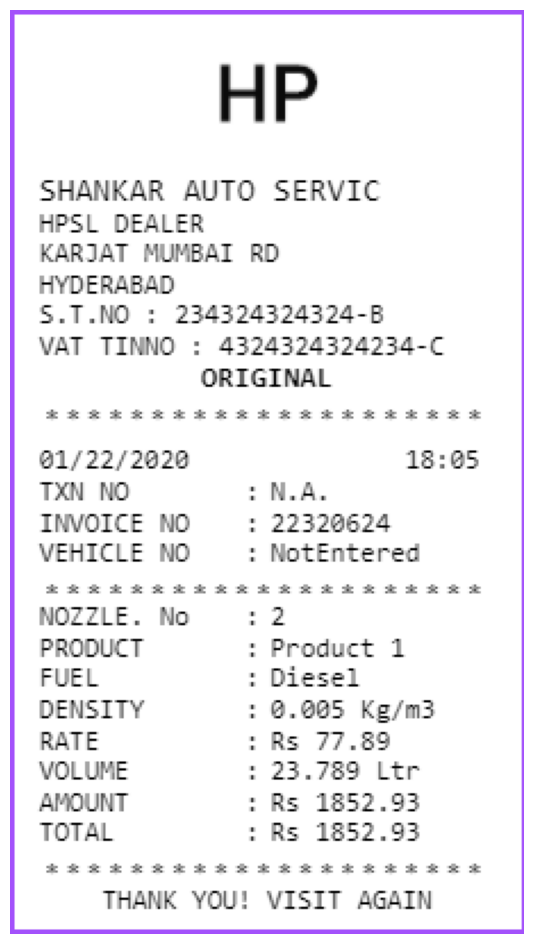

In [ ]:
def process_image_with_model(image_path, text_prompt='receipt', box_threshold=0.35, text_threshold=0.25):
    HOME = os.getcwd()
    CONFIG = os.path.join('/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py')
    WEIGHTS_NAME = 'groundingdino_swint_ogc.pth'
    WEIGHTS_PATH = os.path.join('weights', WEIGHTS_NAME)

    model = load_model(CONFIG, WEIGHTS_PATH)
    image_source, image = load_image(image_path)

    boxes, logits, phrases = predict(
        model=model,
        image=image,
        caption=text_prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold
    )

    annotated_frame = annotate(
        image_source=image_source,
        boxes=boxes,
        logits=logits,
        phrases=phrases
    )
    cv2.imwrite('annotated_frame.jpg', annotated_frame)
    sv.plot_image(annotated_frame)

    return image_source, image, boxes, logits, phrases, annotated_frame, model

# Example usage:
IMAGE_PATH = os.path.join(os.getcwd(), 'data', 'receipt.jpg')
image_source, image, boxes, logits, phrases, annotated_frame, model = process_image_with_model(IMAGE_PATH)

# 2. Generate receipt mask

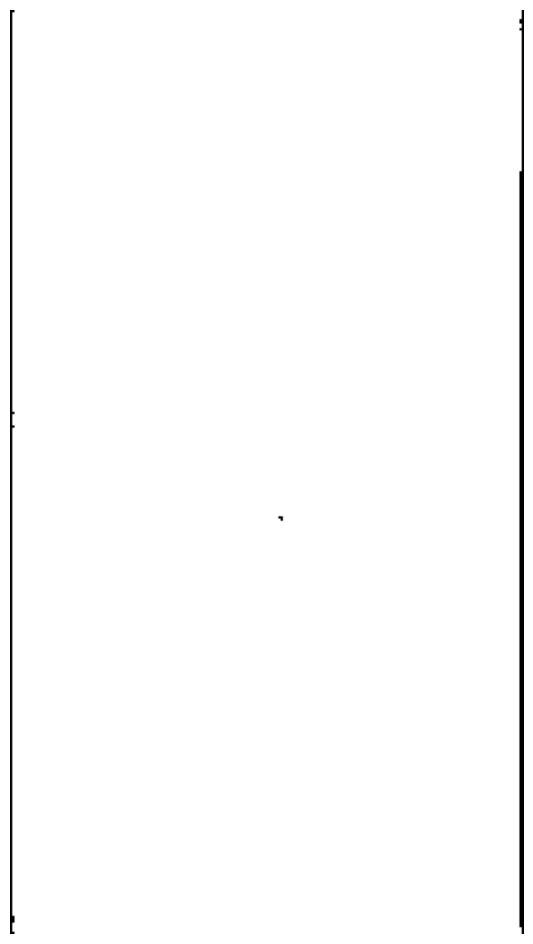

In [ ]:
def process_image_with_sam(image_path,  model, box_threshold=0.35, text_threshold=0.25, text_prompt='receipt', model_type='vit_h', sam_checkpoint_path=None):
    image_source, image = load_image(image_path)
    h, w, _ = image_source.shape

    boxes, logits, phrases = predict(
        model=model,
        image=image,
        caption=text_prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold
    )

    box = boxes[0] * torch.Tensor([w, h, w, h])
    box[:2] -= box[2:] / 2
    box[2:] += box[:2]
    x0, y0, x1, y1 = box.int().tolist()
    input_box = np.array([x0,y0,x1,y1])
    input_point = None
    input_label = None

    img = image_source

    if sam_checkpoint_path is None:
        SAM_CHECKPOINT_PATH = os.path.join(os.getcwd(), 'checkpoints/sam_vit_h_4b8939.pth')
    else:
        SAM_CHECKPOINT_PATH = sam_checkpoint_path

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    sam = sam_model_registry[model_type](checkpoint=SAM_CHECKPOINT_PATH).to(device=device)

    predictor = SamPredictor(sam)
    predictor.set_image(img)

    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box,
        multimask_output=False
    )

    sv.plot_image(masks[0])

    return masks, img

# Example usage:
IMAGE_PATH = os.path.join(os.getcwd(), 'data', 'receipt.jpg')
masks, img = process_image_with_sam(IMAGE_PATH, model)


# 3. Segment receipt from image

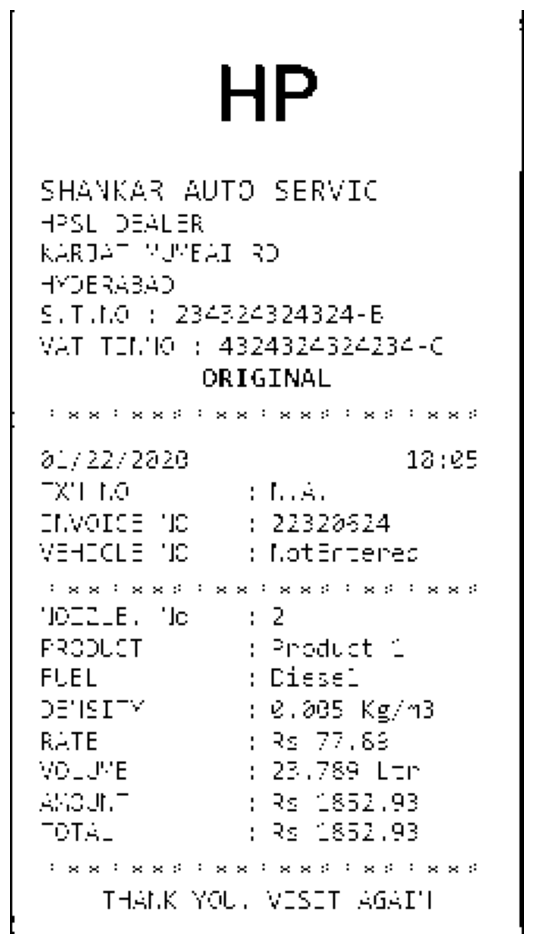

In [ ]:
import cv2

def post_process_segmentation(masks, original_image):
    mask = np.expand_dims(masks[0], axis=0)
    mask = mask.transpose(1,2,0)
    mask = np.array(mask*255).astype('uint8')
    mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    segmented_image = mask
    segmented_image = cv2.bitwise_or(segmented_image, mask)

    segmented_image = cv2.bitwise_and(segmented_image, original_image)

    segmented_image_gray = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(segmented_image_gray, 127, 255, 0)

    sv.plot_image(thresh)

    # Save the thresholded image
    cv2.imwrite('segmented_image.jpg', thresh)

    return thresh

# Example usage:
thresh = post_process_segmentation(masks, img)

# 4. Top-down perspective transform of image

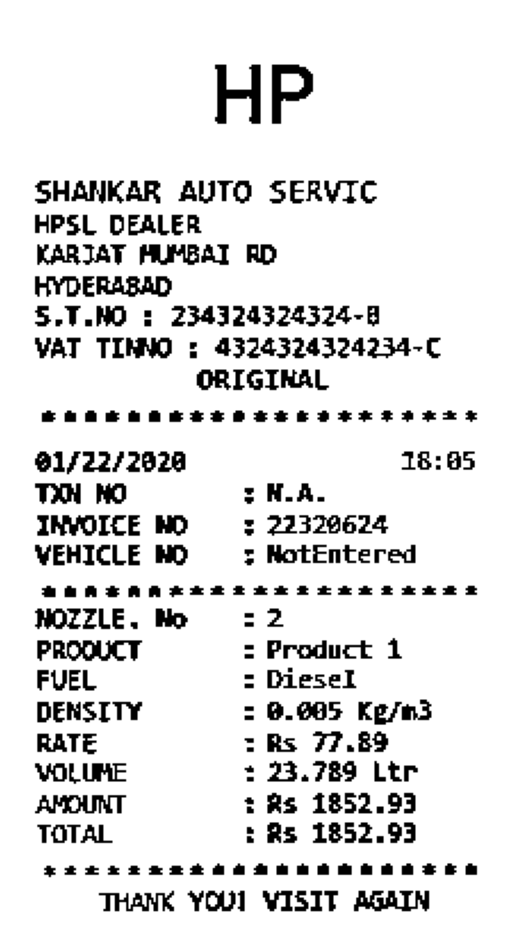

True

In [ ]:
from skimage.filters import threshold_local
from PIL import Image

def opencv_resize(image, ratio):
    width = int(image.shape[1] * ratio)
    height = int(image.shape[0] * ratio)
    dim = (width, height)
    return cv2.resize(image, dim, interpolation = cv2.INTER_AREA)

def approximate_contour(contour):
    peri = cv2.arcLength(contour, True)
    return cv2.approxPolyDP(contour, 0.032 * peri, True)

def get_receipt_contour(contours):
    for c in contours:
        approx = approximate_contour(c)
        if len(approx) == 4:
            return approx

def wrap_perspective(img, rect):
    (tl, tr, br, bl) = rect

    maxWidth = max(int(np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))),
                   int(np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))))
    maxHeight = max(int(np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))),
                    int(np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))))

    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    M = cv2.getPerspectiveTransform(np.array([tl, tr, br, bl], dtype="float32"), dst)

    warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))

    return warped


def contour_to_rect(contour):
    pts = contour.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect

def bw_scanner(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    T = threshold_local(gray, 21, offset = 5, method = "gaussian")
    return (gray > T).astype("uint8") * 255


image = cv2.imread("segmented_image.jpg")
resize_ratio = 500 / image.shape[0]
original = image.copy()
image = opencv_resize(image, resize_ratio)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_with_contours = cv2.drawContours(img.copy(), contours, -1, (0, 255, 0), 3)

largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

receipt_contour = get_receipt_contour(largest_contours)

image_with_receipt_contour = cv2.drawContours(img.copy(), [receipt_contour], -1, (0, 255, 0), 2)

scanned = wrap_perspective(img.copy(), contour_to_rect(receipt_contour))

scanned_bw = bw_scanner(scanned)
sv.plot_image(scanned_bw)
cv2.imwrite('scanned.jpg', scanned_bw)

# 5. Apply OCR to obtain receipt content

'HP\n\nSHANKAR AUTO SERVIC\nHPSL DEALER\n\nKARIAT AUMBAT RD\n\nHYDERABAD.\n\nS.T.MO 2 234324320326-8\nVAT TIMMS : 4324324324234-C\n\n \n\n \n\n \n\n‘ORIGINAL\n01/22/2028 18:05\nTO NO : WAL\n\nINVOICE MO: 29320624\nVEHICLE MO NotEntered\nMOZZLE, Wo = 2\n\nPROOUCT Product 1\nFUEL Diesel\nDENSITY 9.005 Ke/n3\nRATE 2 Rs 77.89\n‘VOLUME 323.789 Ltr\nAMOUNT Rs 1852.93\nTOTAL Rs 1852.93\n\n \n\nTHANK YOUI VISIT AGAIN\n\n \n\x0c'

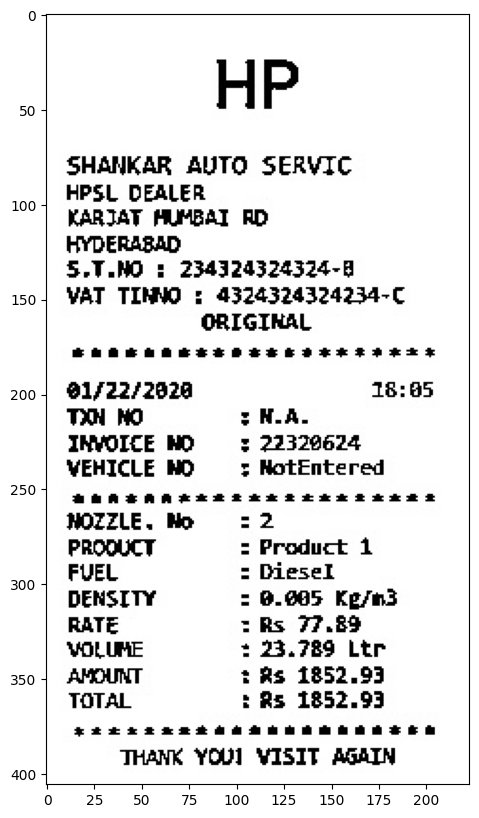

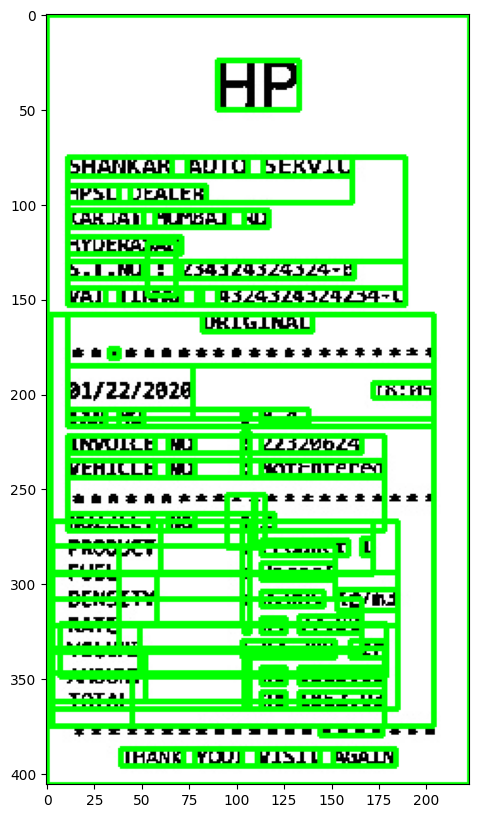

In [ ]:
import cv2
import matplotlib.pyplot as plt
import pytesseract
from pytesseract import Output

def plot_gray(image):
    plt.figure(figsize=(16,10))
    return plt.imshow(image, cmap='Greys_r')

def plot_rgb(image):
    plt.figure(figsize=(16,10))
    return plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

def process_image_and_extract_text(file_name):
    image = cv2.imread(file_name)
    plot_gray(image)

    d = pytesseract.image_to_data(image, output_type=Output.DICT)
    n_boxes = len(d['level'])
    boxes = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)
    for i in range(n_boxes):
        (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
        boxes = cv2.rectangle(boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plot_rgb(boxes)

    extracted_text = pytesseract.image_to_string(image)

    # Save the image with detected text boxes
    cv2.imwrite('boxes_image.jpg', cv2.cvtColor(boxes, cv2.COLOR_RGB2BGR))

    return extracted_text

# Example usage:
process_image_and_extract_text("scanned.jpg")


# Entire Pipeline (i.e Custon Function)

In [ ]:
IMAGE_PATH = os.path.join(os.getcwd(), 'data', 'receipt.jpg')

def process_receipt_image(image_path):

    image_source, image, boxes, logits, phrases, annotated_frame, model = process_image_with_model(image_path)

    masks, img = process_image_with_sam(image_path, model)

    thresh = post_process_segmentation(masks, img)

    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    img_with_contours = cv2.drawContours(img.copy(), contours, -1, (0, 255, 0), 3)

    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    receipt_contour = get_receipt_contour(largest_contours)

    image_with_receipt_contour = cv2.drawContours(img.copy(), [receipt_contour], -1, (0, 255, 0), 2)

    scanned = wrap_perspective(img.copy(), contour_to_rect(receipt_contour))

    scanned_bw = bw_scanner(scanned)
    sv.plot_image(scanned_bw)
    cv2.imwrite('scanned.jpg', scanned_bw)

    extracted_text = process_image_and_extract_text("scanned.jpg")

    return extracted_text

final text_encoder_type: bert-base-uncased


SupervisionWarnings: BoxAnnotator is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


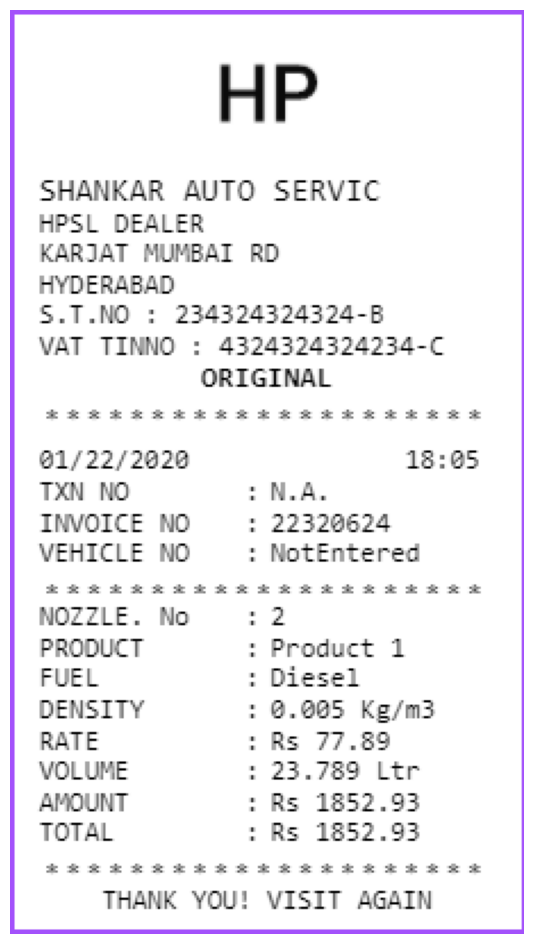

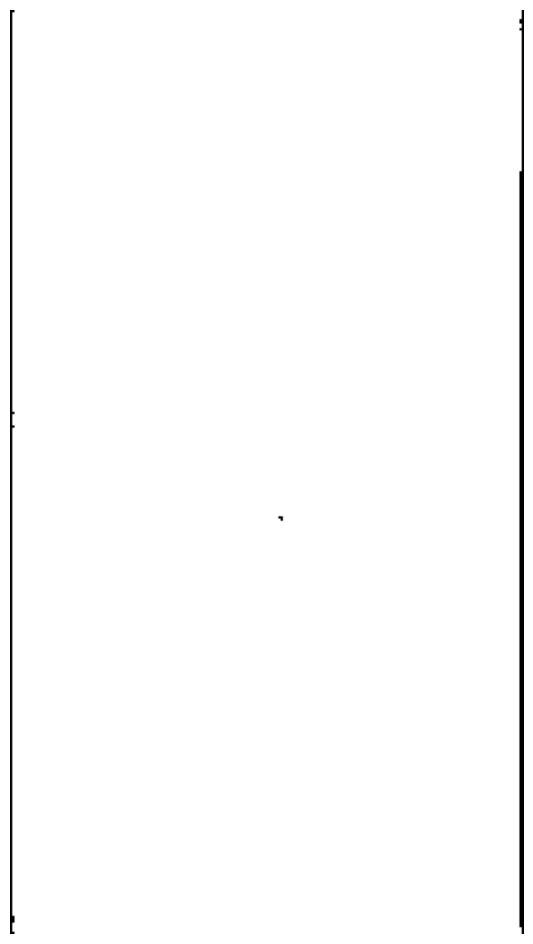

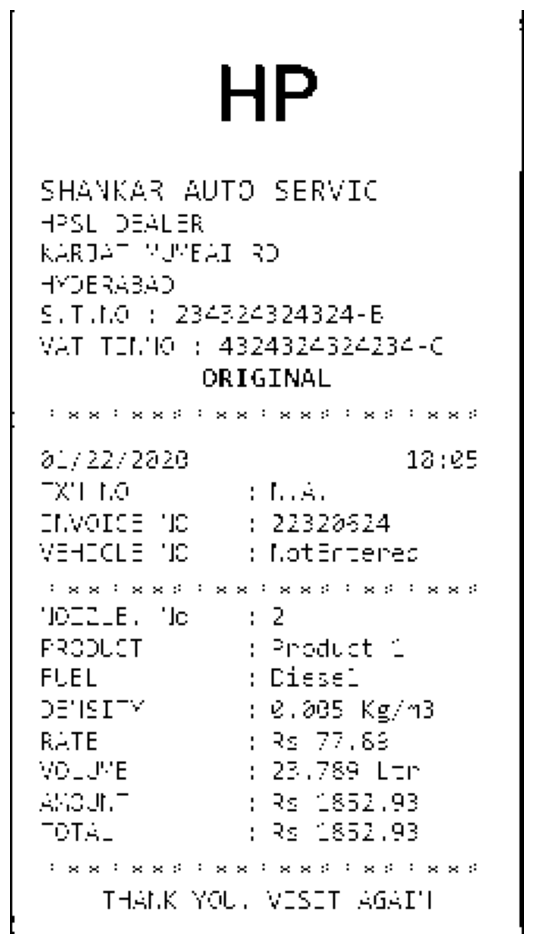

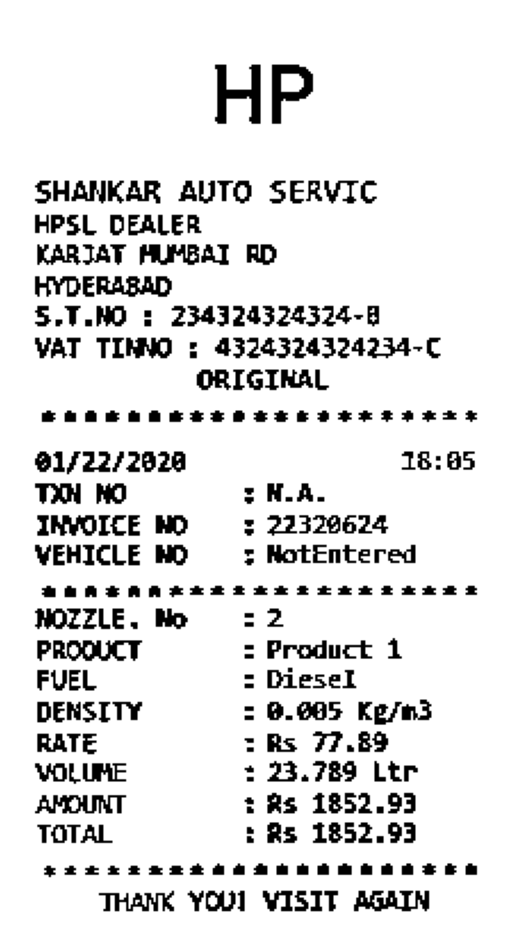

HP

SHANKAR AUTO SERVIC
HPSL DEALER

KARIAT AUMBAT RD

HYDERABAD.

S.T.MO 2 234324320326-8
VAT TIMMS : 4324324324234-C

 

 

 

‘ORIGINAL
01/22/2028 18:05
TO NO : WAL

INVOICE MO: 29320624
VEHICLE MO NotEntered
MOZZLE, Wo = 2

PROOUCT Product 1
FUEL Diesel
DENSITY 9.005 Ke/n3
RATE 2 Rs 77.89
‘VOLUME 323.789 Ltr
AMOUNT Rs 1852.93
TOTAL Rs 1852.93

 

THANK YOUI VISIT AGAIN

 



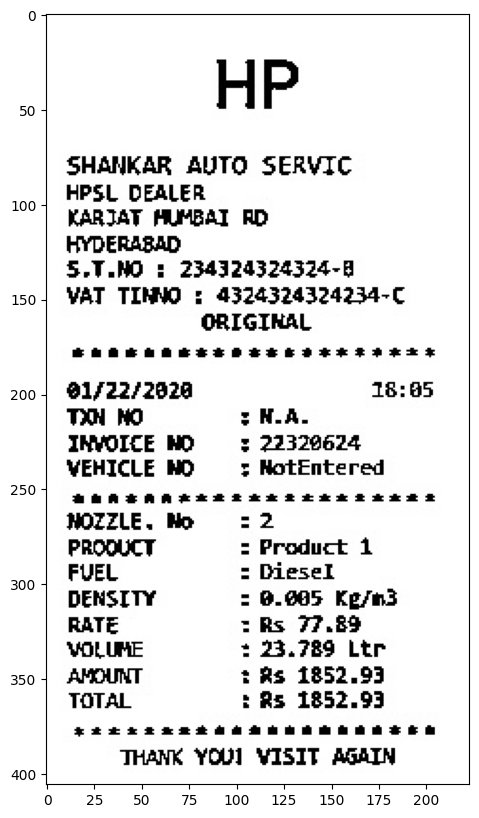

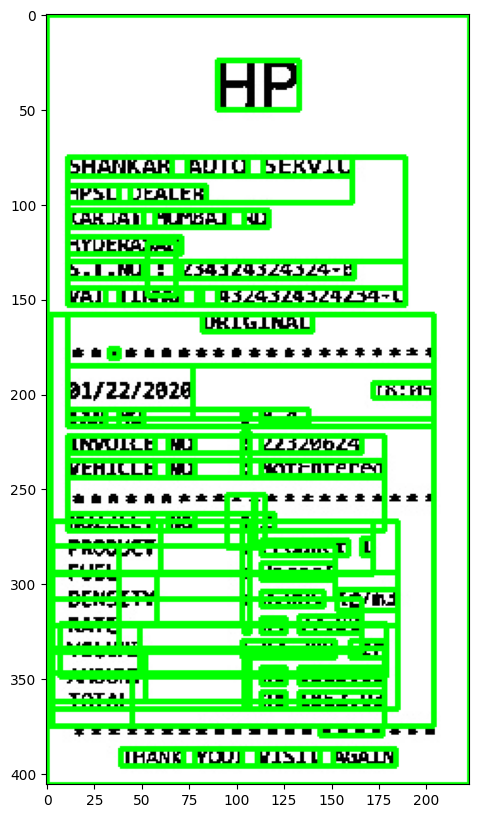

In [ ]:
print(process_receipt_image(IMAGE_PATH))

# LLM Jsonifying

In [ ]:

import torch
from transformers import BitsAndBytesConfig
from langchain.llms.huggingface_pipeline import HuggingFacePipeline
from langchain import PromptTemplate, LLMChain

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
model_id = "mistralai/Mistral-7B-Instruct-v0.1"

model_4bit = AutoModelForCausalLM.from_pretrained( model_id,
                                                  device_map="auto",
                                                   quantization_config=quantization_config, )
tokenizer = AutoTokenizer.from_pretrained(model_id)

pipeline = pipeline(
        "text-generation",
        model=model_4bit,
        tokenizer=tokenizer,
        use_cache=True,
        device_map="auto",
        max_length=2000,
        truncation=True,
        do_sample=True,
        top_k=5,
        num_return_sequences=1,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
)


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

In [ ]:
def generate_response(question, context):
    template = f"""<s>[INST] You are a helpful, respectful and honest assistant. Answer exactly in few words from the context
    Answer the question below from context below :
    {context}
    {question} [/INST] </s>
    """
    llm = HuggingFacePipeline(pipeline=pipeline)

    prompt = PromptTemplate(template=template, input_variables=["question","context"])
    llm_chain = LLMChain(prompt=prompt, llm=llm)
    response = llm_chain.run({"question":question,"context":context})

    return response

# Example usage:
question_p = "What is the date for announcement"
context_p = "On August 10 said that its arm JSW Neo Energy has agreed to buy a portfolio of 1753 mega watt renewable energy generation capacity from Mytrah Energy India Pvt Ltd for Rs 10,530 crore."

response = generate_response(question_p, context_p)
print(response)


<s>[INST] You are a helpful, respectful and honest assistant. Answer exactly in few words from the context
    Answer the question below from context below :
    On August 10 said that its arm JSW Neo Energy has agreed to buy a portfolio of 1753 mega watt renewable energy generation capacity from Mytrah Energy India Pvt Ltd for Rs 10,530 crore.
    What is the date for announcement [/INST] </s>
    10th


# Gradio

In [ ]:
import os
import requests

def download_images(image_urls, output_dir):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for i, url in enumerate(image_urls):
        try:
            response = requests.get(url)
            if response.status_code == 200:
                with open(os.path.join(output_dir, f"image_{i+1}.jpg"), 'wb') as f:
                    f.write(response.content)
                print(f"Image {i+1} downloaded successfully.")
            else:
                print(f"Failed to download image {i+1}. Status code: {response.status_code}")
        except Exception as e:
            print(f"Error downloading image {i+1}: {e}")

if __name__ == "__main__":
    # List of image URLs to download
    image_urls = [
        "https://d1avenlh0i1xmr.cloudfront.net/df06b68a-e1a4-40a2-9504-42c0d9cdbaac/8-real-bill-of-restraunt-with-gst.jpg",
        "https://i0.wp.com/yummraj.com/wp-content/uploads/2015/11/img_0722.jpg?ssl=1",
        "https://pbs.twimg.com/media/Ec0d9Z_U8AAOZ6c.jpg:large",
    ]

    # Output directory
    output_directory = "examples"

    download_images(image_urls, output_directory)


Image 1 downloaded successfully.
Image 2 downloaded successfully.
Image 3 downloaded successfully.


In [ ]:
from pdf2image import convert_from_path
import fitz

def gradio_output(uploaded_file):

  # Process based on file type
  allowed_extensions = ['.jpg', '.jpeg', '.png']
  if any(ext in uploaded_file for ext in allowed_extensions):
      image = Image.open(uploaded_file)
  elif '.pdf' in uploaded_file:
      # Convert first page of PDF to image
      pdf_document = fitz.open(uploaded_file)

      # Get the first page
      first_page = pdf_document[0]

      # Render the first page as an image
      image = first_page.get_pixmap()

      # Convert the image to Pillow Image
      image = Image.frombytes("RGB", [image.width, image.height], image.samples)

  else:
      return "Unsupported file format", None

  if image.mode == 'RGBA':
        image = image.convert('RGB')

  image_path = "uploaded_image.jpg"
  image.save(image_path)

  extracted_text = process_receipt_image("/content/GroundingDINO/uploaded_image.jpg")

  question = """Provide the invoice data in json format
  (NOTE: Only provide answer as JSON nothing else, also there might be spelling mistakes and data extracted from
  invoice could be raw and there might be some mistakes in understanding the data but your job is to intelligently
  indentify and fill in according to your understanding)
  """

  context = f"""
  Extracted Invoice data:

  {extracted_text}
  """

  response = generate_response(question, context)

  return response, Image.open("/content/GroundingDINO/boxes_image.jpg")


In [ ]:
print(gradio_output("/content/GroundingDINO/data/receipt.jpg"))

In [ ]:
demo = gr.Interface(
    gradio_output,
    inputs= gr.File(label="Upload your file"),
    outputs=["textbox", "image"],
    examples=[os.path.join("examples", f) for f in os.listdir("examples")],
)

if __name__ == "__main__":
    demo.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://009cbf77b8edb29181.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


# Comments

In [ ]:
# import os
# from groundingdino.util.inference import load_model, load_image, predict, annotate
# import supervision as sv

# HOME = os.getcwd()
# CONFIG = os.path.join('/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py')

# WEIGHTS_NAME = 'groundingdino_swint_ogc.pth'
# WEIGHTS_PATH = os.path.join('weights', WEIGHTS_NAME)

# model = load_model(CONFIG, WEIGHTS_PATH)

# IMAGE_NAME = 'receipt.jpg'
# IMAGE_PATH = os.path.join(HOME, 'data', IMAGE_NAME)

# TEXT_PROMPT = 'receipt'
# BOX_THRESHOLD = 0.35
# TEXT_THRESHOLD = 0.25

# image_source, image = load_image(IMAGE_PATH)

# boxes, logits, phrases = predict(
#     model=model,
#     image=image,
#     caption=TEXT_PROMPT,
#     box_threshold=BOX_THRESHOLD,
#     text_threshold=TEXT_THRESHOLD
# )

# annotated_frame = annotate(
#     image_source=image_source,
#     boxes=boxes,
#     logits=logits,
#     phrases=phrases
# )


# sv.plot_image(annotated_frame)

In [ ]:
# h, w, _ = image_source.shape
# box = boxes[0] * torch.Tensor([w, h, w, h])
# box[:2] -= box[2:] / 2
# box[2:] += box[:2]
# x0, y0, x1, y1 = box.int().tolist()
# input_box = np.array([x0,y0,x1,y1])
# input_point = None
# input_label = None

# img = image_source

# MODEL_TYPE = 'vit_h'
# SAM_CHECKPOINT_PATH = os.path.join(os.getcwd(), 'checkpoints/sam_vit_h_4b8939.pth')

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT_PATH).to(device=device)

# predictor = SamPredictor(sam)
# predictor.set_image(img)

# masks, scores, _ = predictor.predict(
#     point_coords=None,
#     point_labels=None,
#     box=input_box,
#     multimask_output=False
# )

# sv.plot_image(masks[0])

In [ ]:
# mask = np.expand_dims(masks[0], axis=0)
# mask = mask.transpose(1,2,0)
# mask = np.array(mask*255).astype('uint8')
# mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

# segmented_image = mask
# segmented_image = cv2.bitwise_or(segmented_image, mask)

# segmented_image = cv2.bitwise_and(segmented_image, img)

# segmented_image2 = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2GRAY)
# ret, thresh = cv2.threshold(segmented_image2, 127, 255, 0)

# sv.plot_image(thresh)

# # Save the thresholded image
# cv2.imwrite('segmented_image.jpg', thresh)

In [ ]:
# import cv2
# import numpy as np
# from skimage.filters import threshold_local

# def opencv_resize(image, ratio):
#     width = int(image.shape[1] * ratio)
#     height = int(image.shape[0] * ratio)
#     dim = (width, height)
#     return cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

# def approximate_contour(contour):
#     peri = cv2.arcLength(contour, True)
#     return cv2.approxPolyDP(contour, 0.032 * peri, True)

# def get_receipt_contour(contours):
#     for c in contours:
#         approx = approximate_contour(c)
#         if len(approx) == 4:
#             return approx

# def wrap_perspective(img, rect):
#     (tl, tr, br, bl) = rect
#     maxWidth = max(int(np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))),
#                    int(np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))))
#     maxHeight = max(int(np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))),
#                     int(np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))))
#     dst = np.array([
#         [0, 0],
#         [maxWidth - 1, 0],
#         [maxWidth - 1, maxHeight - 1],
#         [0, maxHeight - 1]], dtype="float32")
#     M = cv2.getPerspectiveTransform(np.array([tl, tr, br, bl], dtype="float32"), dst)
#     warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))
#     return warped

# def contour_to_rect(contour, resize_ratio):
#     pts = contour.reshape(4, 2)
#     rect = np.zeros((4, 2), dtype="float32")
#     s = pts.sum(axis=1)
#     rect[0] = pts[np.argmin(s)]
#     rect[2] = pts[np.argmax(s)]
#     diff = np.diff(pts, axis=1)
#     rect[1] = pts[np.argmin(diff)]
#     rect[3] = pts[np.argmax(diff)]
#     return rect / resize_ratio

# def bw_scanner(image):
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     T = threshold_local(gray, 21, offset=5, method="gaussian")
#     return (gray > T).astype("uint8") * 255

# # Read the image
# image = cv2.imread("segmented_image.jpg")

# # Downscale image for easier handling
# resize_ratio = 500 / image.shape[0]
# original = image.copy()
# image = opencv_resize(image, resize_ratio)

# # Convert the image to grayscale
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # Apply Gaussian blur to reduce noise
# blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# # Perform edge detection using Canny
# edges = cv2.Canny(blurred, 50, 150)

# # Find contours in the edge-detected image
# contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # Get the largest contour
# receipt_contour = get_receipt_contour(contours)

# # Apply perspective transform to the receipt contour
# scanned = wrap_perspective(image.copy(), contour_to_rect(receipt_contour, resize_ratio))

# # Convert the scanned image to black and white
# scanned_bw = bw_scanner(scanned)

# # Display the scanned image
# plt.imshow(scanned_bw, cmap='gray')
# plt.axis('off')
# plt.show()

# # Save the scanned image
# cv2.imwrite('scanned.jpg', scanned_bw)


In [ ]:
# image = cv2.imread("segmented_image.jpg")
# # Downscale image as finding receipt contour is more efficient on a small image
# resize_ratio = 500 / image.shape[0]
# original = image.copy()

# # Function to resize the image while maintaining aspect ratio
# def maintain_aspect_ratio_resize(image, width=None, height=None, inter=cv2.INTER_AREA):
#     dim = None
#     (h, w) = image.shape[:2]

#     if width is None and height is None:
#         return image

#     if width is None:
#         r = height / float(h)
#         dim = (int(w * r), height)
#     else:
#         r = width / float(w)
#         dim = (width, int(h * r))

#     # resize the image
#     resized = cv2.resize(image, dim, interpolation=inter)

#     # return the resized image
#     return resized

# # Resize image for easier handling
# resized_image = maintain_aspect_ratio_resize(image, width=500)

# # Convert the resized image to grayscale
# gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

# # Use Canny Edge Detection to find edges in the image
# edges = cv2.Canny(gray_image, 50, 150)

# # Find contours based on edges detected
# contours, hierarchy = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # Sort contours based on contour area and ignore small contours
# contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

# # Function to approximate and validate a contour
# def validate_contour(c, min_ratio=0.5, max_ratio=1.5):
#     peri = cv2.arcLength(c, True)
#     approx = cv2.approxPolyDP(c, 0.02 * peri, True)
#     # Check if contour is a quadrilateral
#     if len(approx) == 4:
#         (x, y, w, h) = cv2.boundingRect(approx)
#         aspectRatio = w / float(h)
#         # Check if the contour aspect ratio is within a reasonable range
#         if aspectRatio >= min_ratio and aspectRatio <= max_ratio:
#             return approx
#     return None

# # Iterate over contours to find a valid receipt contour
# for c in contours:
#     rect = validate_contour(c)
#     if rect is not None:
#         break

# # If a valid contour is found, proceed with perspective transform
# if rect is not None:
#     # Draw the contour on the image
#     image_with_contour = cv2.drawContours(resized_image.copy(), [rect], -1, (0, 255, 0), 2)
#     plt.imshow(cv2.cvtColor(image_with_contour, cv2.COLOR_BGR2RGB))
#     plt.title('Image with Contour')
#     plt.axis('off')
#     plt.show()
# else:
#     print("No valid contour found.")


In [ ]:
# # Perspective transform to obtain a top-down view of the receipt
# def order_points(pts):
#     # Initialize a list of coordinates that will be ordered such that:
#     # the first entry in the list is the top-left, the second entry is the top-right,
#     # the third is the bottom-right, and the fourth is the bottom-left
#     rect = np.zeros((4, 2), dtype="float32")

#     # The top-left point will have the smallest sum, whereas the bottom-right will have the largest sum
#     s = pts.sum(axis=1)
#     rect[0] = pts[np.argmin(s)]
#     rect[2] = pts[np.argmax(s)]

#     # The top-right point will have the smallest difference, whereas the bottom-left will have the largest difference
#     diff = np.diff(pts, axis=1)
#     rect[1] = pts[np.argmin(diff)]
#     rect[3] = pts[np.argmax(diff)]

#     return rect

# def four_point_transform(image, pts):
#     # Obtain a consistent order of the points and unpack them individually
#     rect = order_points(pts)
#     (tl, tr, br, bl) = rect

#     # Compute the width of the new image, which will be the maximum distance between bottom-right and bottom-left
#     # x-coordinates or the top-right and top-left x-coordinates
#     widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
#     widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
#     maxWidth = max(int(widthA), int(widthB))

#     # Compute the height of the new image, which will be the maximum distance between the top-right and bottom-right
#     # y-coordinates or the top-left and bottom-left y-coordinates
#     heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
#     heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
#     maxHeight = max(int(heightA), int(heightB))

#     # Construct the set of destination points to obtain a "birds eye view" (i.e., top-down view) of the image,
#     # again specifying points in the top-left, top-right, bottom-right, and bottom-left order
#     dst = np.array([
#         [0, 0],
#         [maxWidth - 1, 0],
#         [maxWidth - 1, maxHeight - 1],
#         [0, maxHeight - 1]], dtype="float32")

#     # Compute the perspective transform matrix and then apply it
#     M = cv2.getPerspectiveTransform(rect, dst)
#     warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

#     # Return the warped image
#     return warped

# # Apply the four point transform to obtain a top-down view of the receipt
# warped = four_point_transform(resized_image, rect.reshape(4, 2))

# # Convert the warped image to grayscale, then threshold it to give it that 'black and white' paper effect
# warped = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
# T = threshold_local(warped, 11, offset=10, method="gaussian")
# warped = (warped > T).astype("uint8") * 255

# # Show the original and scanned images
# plt.figure(figsize=(10,10))
# plt.subplot(1, 2, 1)
# plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
# plt.title('Original Image')
# plt.axis('off')

# plt.subplot(1, 2, 2)
# plt.imshow(warped, cmap='gray')
# plt.title('Scanned Image')
# plt.axis('off')

# plt.show()


In [ ]:
# def plot_gray(image):
#     plt.figure(figsize=(16,10))
#     return plt.imshow(image, cmap='Greys_r')

# def plot_rgb(image):
#     plt.figure(figsize=(16,10))
#     return plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

# file_name = "scanned.jpg"
# image = cv2.imread(file_name)
# plot_gray(image)

# d = pytesseract.image_to_data(image, output_type=Output.DICT)
# n_boxes = len(d['level'])
# boxes = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)
# for i in range(n_boxes):
#     (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
#     boxes = cv2.rectangle(boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

# plot_rgb(boxes)

# extracted_text = pytesseract.image_to_string(image)
# print(extracted_text)